In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ISY503 Assessment 3 — Amazon Review Sentiment Analysis

## Project overview
This group project creates a sentiment analysis system for Amazon product reviews. The aim is to classify a review as positive or negative.

The project was developed by the group from the beginning, following the main requirements of the assessment. The process included preparing and cleaning the review data, splitting the data into training, validation and test sets, training neural network models, comparing their performance, testing the final model with new reviews, and creating a simple web application using Streamlit.

### Final workflow used in this notebook

Dataset - data cleaning - train/validation/test split - text tokenisation - padding - model training - baseline vs BiLSTM comparison - model selection - final testing - error analysis - testing new reviews - Streamlit application


### Group development evidence
The project was created by the group using the Amazon review dataset.

* During the development process, the group:
* loaded and prepared the positive and negative review data;
* cleaned the text and removed unsuitable reviews;
* split the data into training, validation and test sets;
* created a baseline neural network and a BiLSTM model;
* compared both models using validation results;
* selected the better-performing model;
* evaluated the final model using test data;
* added a confusion matrix and error analysis;
* tested the model with new reviews;
* created and tested a Streamlit web application.

These steps allowed the group to build, test and evaluate the sentiment analysis system as a complete project.

In [ ]:
# 1. Import Libraries
import pandas as pd
import os
import re

## 1. Dataset acquisition and loading

The Amazon product review dataset linked in the assessment brief as used in this project. The dataset includes positive and negative reviews from four categories: books, DVD, electronics, and kitchen & housewares.

For this project, we used only the labelled reviews. Each review was given a simple label:

* 1 = Positive review
* 0 = Negative review

The original review text was kept so it could be cleaned and prepared in the next steps.

In [ ]:
# ======================================================
# 2. Download Dataset
# ======================================================

!wget -O domain_sentiment_data.tar.gz \
"https://www.cs.jhu.edu/~mdredze/datasets/sentiment/domain_sentiment_data.tar.gz"

print("Dataset downloaded successfully.")

--2026-08-18 13:30:54--  https://www.cs.jhu.edu/~mdredze/datasets/sentiment/domain_sentiment_data.tar.gz
Resolving www.cs.jhu.edu (www.cs.jhu.edu)... 128.220.13.64
Connecting to www.cs.jhu.edu (www.cs.jhu.edu)|128.220.13.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30586147 (29M) [application/x-gzip]
Saving to: ‘domain_sentiment_data.tar.gz’

domain_sentiment_da 100%[===================>]  29.17M  8.33MB/s    in 3.5s    

2026-08-18 13:30:59 (8.33 MB/s) - ‘domain_sentiment_data.tar.gz’ saved [30586147/30586147]

Dataset downloaded successfully.


In [ ]:
# ======================================================
# 3. Extract Dataset
# ======================================================

import tarfile

tar_file = "domain_sentiment_data.tar.gz"

with tarfile.open(tar_file, "r:gz") as tar:
    tar.extractall("amazon_sentiment_data")

print("Complete dataset extracted successfully.")

/tmp/ipykernel_6735/3172255654.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("amazon_sentiment_data")


Complete dataset extracted successfully.


In [ ]:
# ======================================================
# 4. Inspect Dataset Structure
# ======================================================

# Display the extracted folders before loading the data.
for root, folders, files in os.walk("amazon_sentiment_data"):
    print(root, folders, files[:3])

amazon_sentiment_data ['sorted_data_acl'] []
amazon_sentiment_data/sorted_data_acl ['books', 'electronics', 'dvd', 'kitchen_&_housewares'] []
amazon_sentiment_data/sorted_data_acl/books [] ['negative.review', 'positive.review']
amazon_sentiment_data/sorted_data_acl/electronics [] ['negative.review', 'positive.review', 'unlabeled.review']
amazon_sentiment_data/sorted_data_acl/dvd [] ['negative.review', 'positive.review', 'unlabeled.review']
amazon_sentiment_data/sorted_data_acl/kitchen_&_housewares [] ['negative.review', 'positive.review', 'unlabeled.review']


In [ ]:
# ======================================================
# 5. Define the Review Loading Function
# ======================================================

def load_reviews(file_path, label):
    """
    Extract review text and assign its sentiment label.

    Parameters:
        file_path (str): Path to the review file.
        label (int): Sentiment label (1 = positive, 0 = negative).

    Returns:
        list: Review text and sentiment labels.
    """

    with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
        content = file.read()

    # Extract only the text contained within each review_text tag.
    review_texts = re.findall(
        r"<review_text>(.*?)</review_text>",
        content,
        flags=re.DOTALL
    )

    reviews = []

    for review_text in review_texts:
        cleaned_text = review_text.strip()

        if cleaned_text:
            reviews.append({
                "review": cleaned_text,
                "label": label
            })

    return reviews

In [ ]:
# ======================================================
# 6. Load All Labelled Reviews
# ======================================================

# Load positive and negative reviews from all product categories.
DATASET_PATH = "amazon_sentiment_data/sorted_data_acl"

categories = [
    "books",
    "dvd",
    "electronics",
    "kitchen_&_housewares"
]

all_reviews = []

for category in categories:

    positive_path = os.path.join(DATASET_PATH, category, "positive.review")
    negative_path = os.path.join(DATASET_PATH, category, "negative.review")

    positive_data = load_reviews(positive_path, label=1)
    negative_data = load_reviews(negative_path, label=0)

    # Add the product category to each review.
    for review in positive_data:
        review["category"] = category

    for review in negative_data:
        review["category"] = category

    all_reviews.extend(positive_data)
    all_reviews.extend(negative_data)

reviews_df = pd.DataFrame(all_reviews)

print(f"Total reviews: {len(reviews_df)}")
print("\nSentiment distribution:")
print(reviews_df["label"].value_counts())

print("\nCategory distribution:")
print(reviews_df["category"].value_counts())

Total reviews: 8000

Sentiment distribution:
label
1    4000
0    4000
Name: count, dtype: int64

Category distribution:
category
books                   2000
dvd                     2000
electronics             2000
kitchen_&_housewares    2000
Name: count, dtype: int64


## 2. Data quality and preprocessing rationale

The original dataset contained 8,000 reviews, with a balanced number of positive and negative reviews across the four product categories. We found 147 duplicated reviews and no missing values.

To prepare the data, we applied a few simple cleaning steps:

* removed duplicated reviews;
* removed reviews with fewer than three words;
* changed the text to lowercase;
* removed line breaks, punctuation and special characters;
* removed extra spaces.

After cleaning, 7,852 reviews remained: 3,970 positive and 3,882 negative.

We also kept the original review text in a separate column so we could later check examples that the model classified incorrectly.

**Limitation:** the cleaning process is simple. It does not correct spelling or fully understand language structure. Also, removing punctuation can affect some words. For example, don't becomes dont, which may make some negative expressions more difficult for the model to understand.

In [ ]:
# ======================================================
# 7. Check Data Quality
# ======================================================

# Check for missing values, duplicated reviews,
# and review length before preprocessing.
print("Missing values:")
print(reviews_df.isnull().sum())

print("\nDuplicated reviews:")
print(reviews_df.duplicated(subset="review").sum())

reviews_df["word_count"] = reviews_df["review"].str.split().str.len()

print("\nReview length statistics:")
print(reviews_df["word_count"].describe())

Missing values:
review      0
label       0
category    0
dtype: int64

Duplicated reviews:
147

Review length statistics:
count    8000.000000
mean      135.251500
std       150.860587
min         1.000000
25%        49.000000
50%        90.000000
75%       162.000000
max      3393.000000
Name: word_count, dtype: float64


In [ ]:
# ======================================================
# 8. Remove Duplicate Reviews
# ======================================================

# Remove duplicated reviews to avoid training
# the model multiple times with the same sample.
reviews_df = reviews_df.drop_duplicates(
    subset="review"
).reset_index(drop=True)

print(f"Total reviews after removing duplicates: {len(reviews_df)}")

print("\nSentiment distribution:")
print(reviews_df["label"].value_counts())

Total reviews after removing duplicates: 7853

Sentiment distribution:
label
1    3971
0    3882
Name: count, dtype: int64


In [ ]:
# ======================================================
# 9. Remove Very Short Reviews
# ======================================================

# Remove reviews with fewer than three words because
# they provide insufficient information for sentiment analysis.
MIN_REVIEW_LENGTH = 3

reviews_df = reviews_df[
    reviews_df["word_count"] >= MIN_REVIEW_LENGTH
].reset_index(drop=True)

print(f"Total reviews after removing short reviews: {len(reviews_df)}")

print("\nSentiment distribution:")
print(reviews_df["label"].value_counts())

Total reviews after removing short reviews: 7852

Sentiment distribution:
label
1    3970
0    3882
Name: count, dtype: int64


In [ ]:
# ======================================================
# 10. Apply Text Cleaning
# ======================================================
# Standardise review text before tokenisation.
def clean_text(text):

    text = text.lower()
    text = text.replace("\n", " ")

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# Create a cleaned version of each review while
# preserving the original text for future reference.
reviews_df["clean_review"] = reviews_df["review"].apply(clean_text)

reviews_df[["review", "clean_review", "label"]].head()

,review,clean_review,label
0,Sphere by Michael Crichton is an excellant nov...,sphere by michael crichton is an excellant nov...,1
1,Dr. Oz is an accomplished heart surgeon in the...,dr oz is an accomplished heart surgeon in the ...,1
2,The most gorgeous artwork in comic books. Cont...,the most gorgeous artwork in comic books conta...,1
3,This book is for lovers of Robicheaux. His de...,this book is for lovers of robicheaux his demo...,1
4,This is going to be a short and sweet review b...,this is going to be a short and sweet review b...,1


## 3. Data splitting and leakage control

After cleaning, the dataset was divided into three groups:

* Training: 5,496 reviews
* Validation: 1,178 reviews
* Test: 1,178 reviews

A **70/15/15** split was used, while keeping a similar balance of positive and negative reviews in each group.

The training set was used to train the models. The validation set was used to compare model performance and support early stopping. The test set was reserved for the final evaluation of the selected model.

The tokeniser was fitted only on the training data. This helped prevent information from the validation and test sets from influencing the training process, making the final results more reliable.

In [ ]:
# ======================================================
# 11. Split the Dataset
# ======================================================

# Split the cleaned reviews into training,
# validation and testing datasets.
from sklearn.model_selection import train_test_split

X_text = reviews_df["clean_review"]
y = reviews_df["label"]

# First split: 70% training and 30% temporary.
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide the remaining 30%
# into validation and testing datasets.
X_validation_text, X_test_text, y_validation, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_validation_text))
print("Test samples:", len(X_test_text))

Training samples: 5496
Validation samples: 1178
Test samples: 1178


## 4. Text encoding and sequence length

The tokeniser uses a maximum vocabulary of 10,000 words. Words that are not included in the vocabulary are represented using the OOV token.

Each review was converted into a sequence of numbers so it could be processed by the neural network. All sequences were set to a maximum length of 200 tokens.

The review lengths were checked using only the training data. Around 81.33% of the training reviews contained 200 words or fewer, so a length of 200 was considered suitable for most reviews.

Reviews longer than 200 tokens were shortened, while shorter reviews were padded to reach the same length.

In [ ]:
# ======================================================
# 12. Tokenise the Text
# ======================================================

# Learn the vocabulary from the training reviews only.
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [ ]:
# ======================================================
# 13. Encode the Reviews
# ======================================================

# Convert each review into a sequence of integer tokens.
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_validation_seq = tokenizer.texts_to_sequences(X_validation_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [ ]:
# ======================================================
# 14. Pad the Sequences
# ======================================================

# Ensure all review sequences have the same length.
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_SEQUENCE_LENGTH = 200

X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_validation = pad_sequences(
    X_validation_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Training set:", X_train.shape)
print("Validation set:", X_validation.shape)
print("Test set:", X_test.shape)

Training set: (5496, 200)
Validation set: (1178, 200)
Test set: (1178, 200)


In [ ]:
# ======================================================
# 14A. Justify Maximum Sequence Length
# ======================================================

train_lengths = X_train_text.str.split().str.len()

print("Training review length percentiles:")
print(train_lengths.quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

percentage_within_200 = (train_lengths <= 200).mean() * 100

print(
    f"\nPercentage of training reviews with 200 words or fewer: "
    f"{percentage_within_200:.2f}%"
)

Training review length percentiles:
0.50     91.00
0.75    163.00
0.90    290.00
0.95    414.25
0.99    705.00
Name: clean_review, dtype: float64

Percentage of training reviews with 200 words or fewer: 81.33%


## 5. Neural-network experiment: Baseline vs BiLSTM

Two neural network models were tested under the same training conditions to compare their performance.

### Baseline neural network
The baseline uses:

**Embedding - GlobalAveragePooling1D - Dense(32, ReLU) - Dropout(0.3) - Sigmoid output**

This provides a simpler reference model with 642,113 trainable parameters.

### BiLSTM neural network
The BiLSTM uses:

**Embedding - Bidirectional LSTM(32) - Dropout(0.3) - Sigmoid output**

It has 664,897 trainable parameters and is designed to model word order and sequential context in both directions.

The code heading describes the BiLSTM as “Improved” because it is architecturally more complex. This does **not** mean it achieved better results. Final model selection is based on observed validation performance.


In [ ]:
# ======================================================
# 15. Build Baseline Neural Network
# ======================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

BASELINE_EMBEDDING_DIM = 64

baseline_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=BASELINE_EMBEDDING_DIM,
        mask_zero=True
    ),

    GlobalAveragePooling1D(),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,113 (2.45 MB)

 Trainable params: 642,113 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ======================================================
# 16. Build the Improved BiLSTM Neural Network
# ======================================================

# Use masking and bidirectional processing to improve
# context learning while ignoring padded values.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

EMBEDDING_DIM = 64

bilstm_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,897 (2.54 MB)

 Trainable params: 664,897 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Fair comparison and training procedure

Both models were trained using the same settings:

* the same training, validation and test datasets;
* vocabulary size and sequence length;
* 64-dimensional embedding;
* Adam optimiser with a learning rate of 0.001;
* binary cross-entropy loss;
* batch size of 32;
* maximum of 10 epochs;
* early stopping based on validation loss.

Using the same settings made the comparison between the two models more consistent.

Early stopping was used to stop training when the validation loss stopped improving. The best model weights were then restored automatically.


In [ ]:
# ======================================================
# 17. Compile Both Neural Networks
# ======================================================

from tensorflow.keras.optimizers import Adam

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Both models compiled successfully.")

Both models compiled successfully.


In [ ]:
# ======================================================
# 18. Train the Baseline Neural Network
# ======================================================

from tensorflow.keras.callbacks import EarlyStopping

# Stop training when validation loss stops improving.
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=10,
    batch_size=32,
    callbacks=[baseline_early_stopping],
    verbose=1
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6756 - loss: 0.6499 - val_accuracy: 0.7716 - val_loss: 0.5468
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8290 - loss: 0.4214 - val_accuracy: 0.7988 - val_loss: 0.4264
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9088 - loss: 0.2668 - val_accuracy: 0.7827 - val_loss: 0.4643
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9465 - loss: 0.1766 - val_accuracy: 0.8005 - val_loss: 0.4676


In [ ]:
# ======================================================
# 19. Train the Improved BiLSTM Neural Network
# ======================================================

bilstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

bilstm_history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=10,
    batch_size=32,
    callbacks=[bilstm_early_stopping],
    verbose=1
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 49s 254ms/step - accuracy: 0.6658 - loss: 0.6094 - val_accuracy: 0.7895 - val_loss: 0.4641
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 45s 262ms/step - accuracy: 0.8544 - loss: 0.3376 - val_accuracy: 0.8073 - val_loss: 0.4687
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 43s 252ms/step - accuracy: 0.9361 - loss: 0.1816 - val_accuracy: 0.7929 - val_loss: 0.5120


## 7. Validation-based model selection

The two models were compared using the validation set.

### Results from the saved run

* Baseline: 79.88% accuracy, 0.4264 loss
* BiLSTM: 78.95% accuracy, 0.4641 loss

The baseline model achieved slightly better results, with higher validation accuracy and lower validation loss.

For this reason, the baseline model was selected as the final model.

This result also shows that a more complex model does not always perform better.


In [ ]:
# ======================================================
# 20. Compare Model Performance
# ======================================================

# Evaluate both models on the validation set.
baseline_val_loss, baseline_val_accuracy = baseline_model.evaluate(
    X_validation,
    y_validation,
    verbose=0
)

bilstm_val_loss, bilstm_val_accuracy = bilstm_model.evaluate(
    X_validation,
    y_validation,
    verbose=0
)

print("MODEL COMPARISON - VALIDATION SET")
print("----------------------------------")

print(
    f"Baseline Model  - "
    f"Accuracy: {baseline_val_accuracy:.4f} | "
    f"Loss: {baseline_val_loss:.4f}"
)

print(
    f"BiLSTM Model    - "
    f"Accuracy: {bilstm_val_accuracy:.4f} | "
    f"Loss: {bilstm_val_loss:.4f}"
)

MODEL COMPARISON - VALIDATION SET
----------------------------------
Baseline Model  - Accuracy: 0.7988 | Loss: 0.4264
BiLSTM Model    - Accuracy: 0.7895 | Loss: 0.4641


## 8. Final test evaluation

After selecting the final model, the baseline model was evaluated using the test set.


### Test result from the saved run

* Test accuracy: 80.05%
* Test loss: 0.4151

The test accuracy was close to the validation accuracy, showing that the model performed in a similar way on new data.



In [ ]:
# ======================================================
# 21. Evaluate the Selected Model on the Test Set
# ======================================================

test_loss, test_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("FINAL MODEL - TEST SET")
print("----------------------")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

FINAL MODEL - TEST SET
----------------------
Test Accuracy: 0.8005
Test Loss: 0.4151


In [ ]:
# ======================================================
# 22. Generate Test Predictions
# ======================================================

# Convert predicted probabilities into binary sentiment labels.
y_pred_prob = baseline_model.predict(X_test, verbose=0)

# 1 = Positive, 0 = Negative
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print("Test predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Test predictions generated successfully.
Number of predictions: 1178


## 9. Class-level performance and confusion matrix

Accuracy gives the overall performance of the model, but the classification report and confusion matrix show more detail about the types of errors.

### Saved-run class performance
- Negative: precision 0.76, recall 0.86, F1-score 0.81
- Positive: precision 0.85, recall 0.74, F1-score 0.79

The confusion matrix shows:

- 503 negative reviews were correctly classified;
- 80 negative reviews were incorrectly classified as positive;
- 155 positive reviews were incorrectly classified as negative;
- 440 positive reviews were correctly classified.

Overall, the model performed similarly for both classes, although it identified negative reviews slightly better than positive reviews.


In [ ]:
# ======================================================
# 23. Display Classification Metrics
# ======================================================

# Report class-level performance and prediction errors.
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.76      0.86      0.81       583
    Positive       0.85      0.74      0.79       595

    accuracy                           0.80      1178
   macro avg       0.81      0.80      0.80      1178
weighted avg       0.81      0.80      0.80      1178

Confusion Matrix:
[[503  80]
 [155 440]]


## 10. Training behaviour and overfitting

The graphs below show the training and validation results for the selected baseline model.

During training, the training accuracy continued to improve, but the validation results stopped improving earlier. The validation loss also started to increase after reaching its best point.

This indicates overfitting, meaning the model was learning the training data better than it was improving on new data.

For this reason, early stopping was used to stop training at the best point and restore the best model weights.

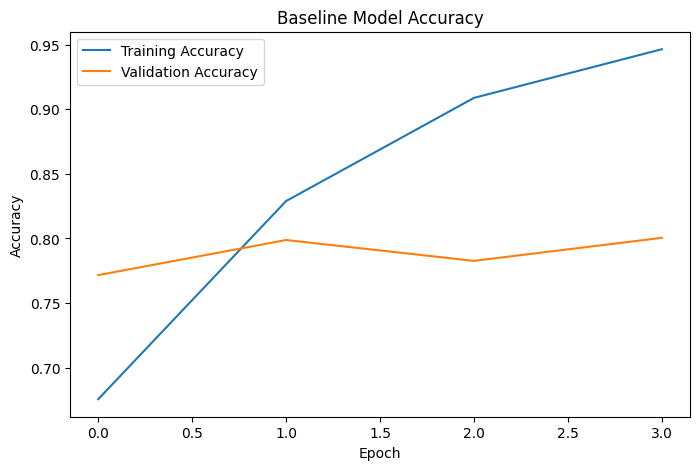

In [ ]:
# ======================================================
# 24. Plot Training History
# ======================================================

# Visualise the learning progress of the selected baseline model.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

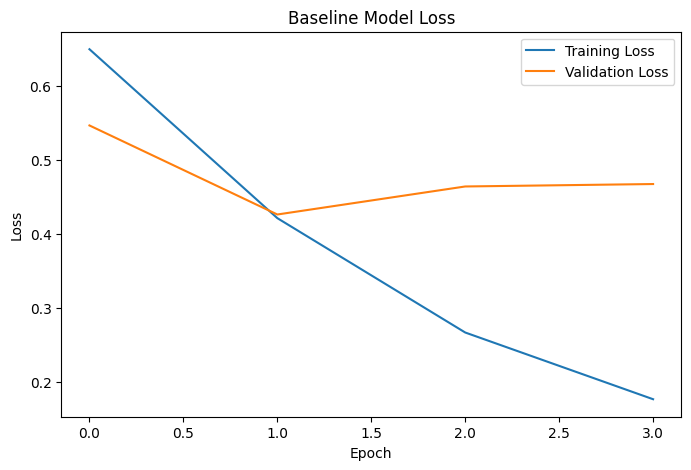

In [ ]:
# Plot training and validation loss.
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

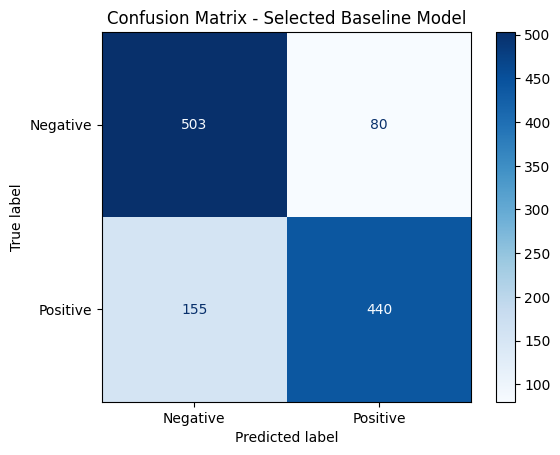

In [ ]:
# ======================================================
# 25. Visualise the Confusion Matrix
# ======================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Selected Baseline Model")
plt.show()

## 11. Error analysis

An error analysis was used to review the test cases that the model classified incorrectly.

In this run, 235 out of 1,178 test reviews were misclassified.

Reviewing these errors helps identify situations that are more difficult for the model. Some reviews may include:

- mixed positive and negative opinions;
- negation;
- specific product language;
- context that is difficult to understand from individual words.

This analysis helps explain the model's limitations beyond the overall accuracy result.

In [ ]:
# ======================================================
# 26. Error Analysis
# ======================================================

# Create a dataframe containing the original test reviews,
# true sentiment labels and predicted sentiment labels.

error_analysis = pd.DataFrame({
    "review": reviews_df.loc[X_test_text.index, "review"],
    "true_label": y_test,
    "predicted_label": y_pred
})

# Identify incorrectly classified reviews.
misclassified = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
].copy()

print("Total misclassified reviews:", len(misclassified))

print("\nExamples of misclassified reviews:")
display(misclassified.head(10))

Total misclassified reviews: 235

Examples of misclassified reviews:


,review,true_label,predicted_label
2269,From the Sociobiological aspect the movie conv...,1,0
929,It's been around two years since I first read ...,1,0
4857,I work in a computer lab where we constantly r...,1,0
1198,Book is out of date with modern economic thoug...,0,1
6959,"It's too bad ... I really wanted this to work,...",0,1
594,Horowitz with the help of researchers provides...,1,0
2397,Li is no heavy-weight pianist. Neither is Buni...,1,0
1938,I hold Martin's Song of Ice and Frie series in...,0,1
383,I have a pile of thes books at home & this is ...,1,0
628,I don't know why the other reviewers though it...,1,0


### Error-analysis interpretation

The incorrect predictions do not come from only one type of problem. Some reviews include mixed opinions, indirect language, or negation, which can be more difficult for the model to classify correctly.

For this reason, the model's output should be understood as a prediction based on patterns learned from the dataset, rather than a complete understanding of the reviewer's meaning.


In [ ]:
# ======================================================
# 27. Define the Sentiment Prediction Function
# ======================================================

def predict_sentiment(review_text):
    """
    Predict whether a new product review is positive or negative.

    Args:
        review_text (str): Review entered by the user.

    Returns:
        tuple: Predicted sentiment and model probability.
    """

    # Apply the same cleaning used during model training.
    cleaned_review = clean_text(review_text)

    # Convert the cleaned review into integer tokens.
    review_sequence = tokenizer.texts_to_sequences(
        [cleaned_review]
    )

    # Pad the sequence to the same length used during training.
    padded_sequence = pad_sequences(
        review_sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    # Generate the probability of positive sentiment
    # using the selected baseline model.
    positive_probability = float(
        baseline_model.predict(
            padded_sequence,
            verbose=0
        )[0][0]
    )

    sentiment = (
        "Positive review"
        if positive_probability >= 0.5
        else "Negative review"
    )

    return sentiment, positive_probability

## 12. Inference on unseen reviews

The final model was also tested using new reviews that were not part of the training or test data.

The same cleaning, tokenisation and padding steps were applied before making each prediction.

### Results:

1. Clear positive review - **Positive**, probability 0.9954  
2. Clear negative review - **Negative**, probability 0.0010  
3. Mixed review (*“looks great, but the battery life is disappointing”*) - **Positive**, probability 0.6664  
4. Negated phrase (*“It is not bad for the price”*) - **Negative**, probability 0.0112  
5. Sarcasm-like negative review (*“Great, another product that broke…”*) - **Negative**, probability 0.05577

The model performed well with clear positive and negative reviews. However, it had more difficulty with mixed opinions and negation.

The last example was classified as negative, but this does not mean the model fully understands sarcasm. The prediction may have been influenced by negative words such as broke.


In [ ]:
## ======================================================
# 28. Test the Model on New Unseen Reviews
# ======================================================

unseen_reviews = [
    "This product is excellent and works perfectly. I would definitely buy it again.",
    "Terrible quality. It stopped working after one day and was a complete waste of money.",
    "The product looks great, but the battery life is disappointing.",
    "It is not bad for the price.",
    "Great, another product that broke after only two days."
]

for review in unseen_reviews:
    sentiment, probability = predict_sentiment(review)

    print("Review:", review)
    print("Prediction:", sentiment)
    print(f"Positive probability: {probability:.4f}")
    print("-" * 60)

Review: This product is excellent and works perfectly. I would definitely buy it again.
Prediction: Positive review
Positive probability: 0.9954
------------------------------------------------------------
Review: Terrible quality. It stopped working after one day and was a complete waste of money.
Prediction: Negative review
Positive probability: 0.0010
------------------------------------------------------------
Review: The product looks great, but the battery life is disappointing.
Prediction: Positive review
Positive probability: 0.6664
------------------------------------------------------------
Review: It is not bad for the price.
Prediction: Negative review
Positive probability: 0.0112
------------------------------------------------------------
Review: Great, another product that broke after only two days.
Prediction: Negative review
Positive probability: 0.0577
------------------------------------------------------------


## 13. Saving the final pipeline for deployment

The selected baseline model was saved as sentiment_model.keras.

The tokeniser and preprocessing settings were also saved so the Streamlit application could process new reviews in the same way as the training data.

Saving these files helps keep the final application consistent with the model that was trained and tested.

In [ ]:
# ======================================================
# 29. Save the Selected Trained Model
# ======================================================

# Save the selected baseline model for later use
# in the web application.
baseline_model.save("sentiment_model.keras")

print("Selected baseline model saved successfully.")

Selected baseline model saved successfully.


In [ ]:
# ======================================================
# 30. Save the Tokenizer
# ======================================================

# Save the fitted tokenizer so new reviews are encoded
# using the same vocabulary as the training data.
import json

tokenizer_json = tokenizer.to_json()

with open("tokenizer.json", "w", encoding="utf-8") as file:
    file.write(tokenizer_json)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [ ]:
# ======================================================
# 31. Save Preprocessing Configuration
# ======================================================

model_config = {
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "vocabulary_size": VOCAB_SIZE
}

with open("model_config.json", "w", encoding="utf-8") as file:
    json.dump(model_config, file)

print("Preprocessing configuration saved successfully.")

Preprocessing configuration saved successfully.


In [ ]:
# ======================================================
# 32. Install Streamlit
# ======================================================

# Install Streamlit to build the web interface.
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 107.4 MB/s eta 0:00:00


## 14. Streamlit web interface

A simple web application was created using Streamlit to allow users to test the sentiment model.

The interface includes:

- a text box to enter a product review;
- an Analyse Sentiment button;
- an output showing “Positive review” or “Negative review”;
- the prediction confidence;
basic information about the model and its limitations.

The application uses the saved model, tokeniser and preprocessing settings, so new reviews are processed in the same way as the data used during model training.

### Group modification evidence

The Streamlit application was created as part of the group project to make the trained sentiment model easy to test through a simple web interface

In [ ]:
# ======================================================
# 33. Create the Streamlit Application
# ======================================================


%%writefile app.py

import json
import re

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json


# ======================================================
# Page Configuration
# ======================================================

st.set_page_config(
    page_title="Amazon Review Sentiment Analysis",
    page_icon="🧠",
    layout="centered"
)


# ======================================================
# Load Model and Preprocessing Settings
# ======================================================

@st.cache_resource
def load_resources():

    # Load the selected trained model.
    model = tf.keras.models.load_model(
        "sentiment_model.keras"
    )

    # Load the tokenizer used during training.
    with open(
        "tokenizer.json",
        "r",
        encoding="utf-8"
    ) as file:

        tokenizer = tokenizer_from_json(
            file.read()
        )

    # Load preprocessing configuration.
    with open(
        "model_config.json",
        "r",
        encoding="utf-8"
    ) as file:

        model_config = json.load(file)

    return model, tokenizer, model_config


model, tokenizer, model_config = load_resources()

MAX_SEQUENCE_LENGTH = model_config[
    "max_sequence_length"
]


# ======================================================
# Text Cleaning
# ======================================================

def clean_text(text):
    """Standardise text before tokenisation."""

    text = text.lower()
    text = text.replace("\n", " ")

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


# ======================================================
# Sentiment Prediction
# ======================================================

def predict_sentiment(review_text):
    """Predict the sentiment of a new product review."""

    # Apply the same text cleaning used during training.
    cleaned_review = clean_text(
        review_text
    )

    # Convert the review into the same token representation.
    review_sequence = tokenizer.texts_to_sequences(
        [cleaned_review]
    )

    # Pad the review to the same sequence length used in training.
    padded_sequence = pad_sequences(
        review_sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict probability of positive sentiment.
    positive_probability = float(
        model.predict(
            padded_sequence,
            verbose=0
        )[0][0]
    )

    # Convert probability into sentiment class.
    if positive_probability >= 0.5:

        sentiment = "Positive review"
        confidence = positive_probability

    else:

        sentiment = "Negative review"
        confidence = 1 - positive_probability

    return sentiment, confidence, positive_probability


# ======================================================
# Application Interface
# ======================================================

st.title("🧠 Amazon Review Sentiment Analysis")

st.write(
    "Enter a product review below and the trained neural "
    "network will classify its sentiment as positive or negative."
)

st.divider()


# ======================================================
# Review Form
# ======================================================

with st.form("sentiment_form"):

    review_text = st.text_area(
        "Product review",
        value="",
        placeholder="Example: This product works perfectly and I would buy it again.",
        height=180,
        key="review_input"
    )

    analyse_button = st.form_submit_button(
        "Analyse Sentiment",
        use_container_width=True,
        type="primary"
    )


# ======================================================
# Display Prediction
# ======================================================

if analyse_button:

    if not review_text.strip():

        st.warning(
            "Please enter a review before analysing."
        )

    else:

        try:

            sentiment, confidence, positive_probability = (
                predict_sentiment(review_text)
            )

            st.subheader("Analysis Result")

            if sentiment == "Positive review":

                st.success(
                    f"✅ {sentiment}"
                )

            else:

                st.error(
                    f"❌ {sentiment}"
                )

            st.metric(
                "Confidence",
                f"{confidence:.2%}"
            )

            st.caption(
                f"Positive sentiment probability: "
                f"{positive_probability:.4f}"
            )

        except Exception as error:

            st.error(
                "The review could not be analysed."
            )

            st.exception(error)


# ======================================================
# Model Information
# ======================================================

st.divider()

with st.expander("About the model"):

    st.write("""
    **Task:** Amazon product review sentiment classification

    **Selected model:** Baseline Neural Network

    **Test accuracy:** 80.05%

    **Classes:** Positive and Negative

    **Maximum sequence length:** 200 tokens
    """)


with st.expander("Model limitations"):

    st.write("""
    The model may have difficulty interpreting complex
    language patterns such as:

    - Negation, for example "not bad"
    - Mixed positive and negative opinions
    - Sarcasm
    - Context-dependent language

    Predictions should therefore be interpreted as model
    estimates rather than definitive judgements.
    """)

Writing app.py


## 15. Deployment and demonstration

The Streamlit application runs on port 8501 and uses a temporary Cloudflare tunnel so it can be opened in a web browser.

This allows a user to:

- enter a new product review;
- click Analyse Sentiment;
- receive a Positive review or Negative review result;
- view the prediction confidence.

The complete process is:

User review - text preparation - tokenisation and padding - baseline model - sentiment result - confidence

### Final consistency check before submission

Before submission, the notebook, Streamlit application and presentation should all report the same final model results.


In [ ]:
# ======================================================
# 34. Run the Streamlit Application
# ======================================================

# Stop previous Streamlit and tunnel processes.
!pkill -f streamlit || true
!pkill -f "lt --port" || true
!pkill -f wrangler || true

# Start Streamlit in the background.
!streamlit run app.py \
    --server.port 8501 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

# Give Streamlit time to start.
import time
time.sleep(5)

# Check that Streamlit is running.
print("Streamlit status:")
!curl -s http://localhost:8501/_stcore/health

# Create a Cloudflare Quick Tunnel.
print("\nOpen the trycloudflare.com URL shown below:")
!npx -y wrangler tunnel quick-start http://localhost:8501

^C
^C
^C
Streamlit status:
ok
Open the trycloudflare.com URL shown below:
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦▲ [WARNING] 🚧 `wrangler tunnel quick-start` is an experimental command. Please report any issues to https://github.com/cloudflare/workers-sdk/issues/new/choose


? cloudflared (2026.8.2) is needed but not installed. Download to /root/.config/.wrangler/cloudflared/2026.8.2/cloudflared? › (Y/n)✔ cloudflared (2026.8.2) is needed but not installed. Download to /root/.config/.wrangler/cloudflared/2026.8.2/cloudflared? … yes
2026-08-18T13:35:16Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (h

## 16. Limitations and ethical considerations

The assessment requires consideration of ethical issues and fairness when using sentiment analysis.
The final model has several limitations:

- Existing labels: the model learns from the positive and negative labels already included in the dataset. If some labels are subjective or inconsistent, the model may learn these same issues.

- Language and context: the cleaning process removes punctuation and does not correct spelling. This can make some expressions difficult to understand. For example, “It is not bad for the price” was incorrectly classified as negative.

- Mixed opinions: some reviews contain both positive and negative comments, but the model must still classify them into only one category.

- Limited dataset: the model was trained using four Amazon product categories, so the same performance cannot be expected for every type of review or writing style.

- Different error rates: the model identified negative reviews slightly better than positive reviews, with recall of 0.86 for negative and 0.74 for positive.

- Confidence does not mean certainty: a high confidence score does not always mean the prediction is correct, especially for complex or unclear reviews.

For these reasons, the model results should be interpreted carefully and its limitations should be considered when using the predictions.
